In [199]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

## 1. Data Preparation

In [200]:
# a) Import data

df=pd.read_csv("The_Titanic_dataset.csv")

In [201]:
# Changing column names and dropping duplicates 
df.columns = df.iloc[0]
df=df.drop(index=0)
df=df.reset_index(drop=True)

df.columns.values[3] = "name"

df=df.drop_duplicates()
df=df.drop_duplicates(subset=["name"])
df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2,**,S,03-Jan-90
5,5,3,1,"Abelseth, Miss. Karen Marie",female,16,0,7.65,S,05-Jan-90
6,6,3,1,"Abelseth, Mr. Olaus Jorgensen",male,25,0,7.65,S,06-Jan-90


In [202]:
# Fixing the genders + cleaning the dataset
df.loc[df["name"].str.contains("Mr."), "gender"] = "male"
df.loc[df["name"].str.contains("Mrs."), "gender"] = "female"
df.loc[df["name"].str.contains("Miss."), "gender"] = "female"
df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",male,NaN,2,**,S,03-Jan-90
5,5,3,1,"Abelseth, Miss. Karen Marie",female,16,0,7.65,S,05-Jan-90
6,6,3,1,"Abelseth, Mr. Olaus Jorgensen",male,25,0,7.65,S,06-Jan-90


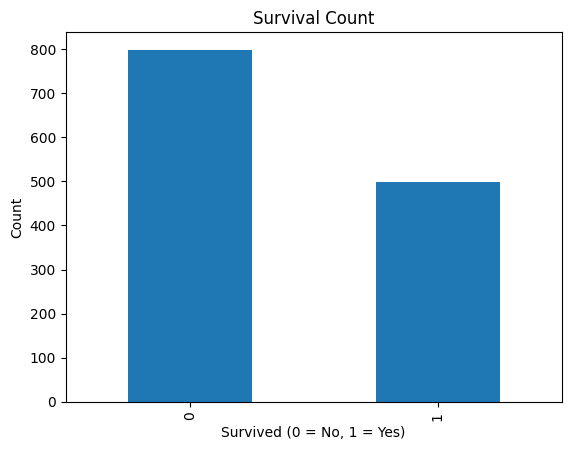

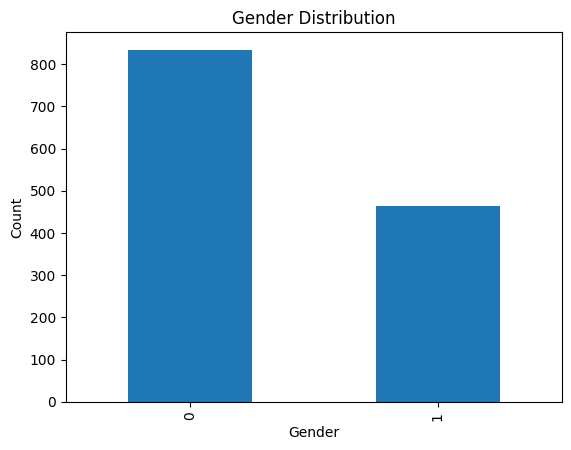

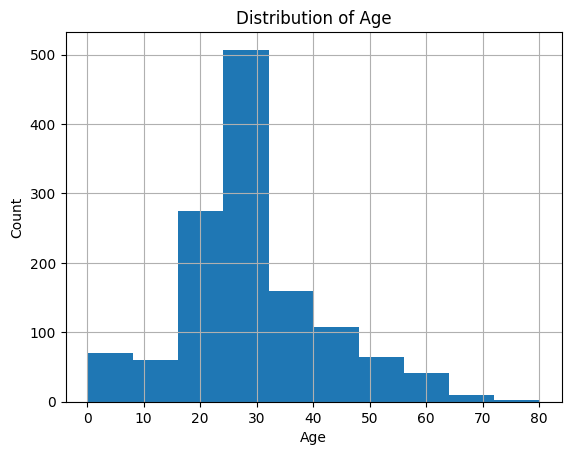

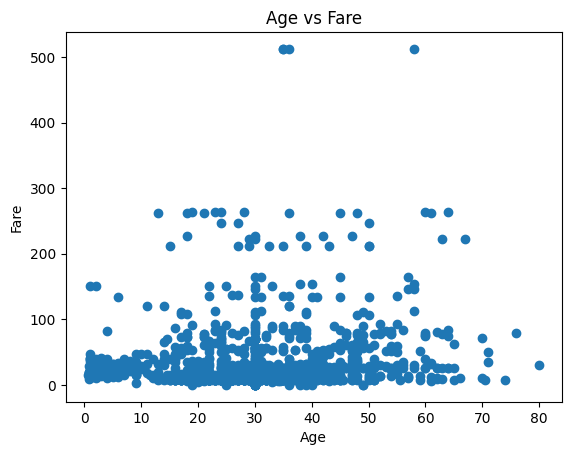

In [203]:
# b) 

df["age"]=df["age"].replace("?", None)
df["age"]=df["age"].astype(float)
df["age"]=df["age"].fillna(df["age"].mean())

df["gender"]=df["gender"].replace("?", None)
df["gender"]=df["gender"].astype(str).str.lower()
df=df[df["gender"].isin(["male", "female"])]
df["gender"]=df["gender"].map({"male": 0, "female": 1})

df["fare"]=df["fare"].replace("**", None)
df["fare"]=df["fare"].astype(float)

df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

df["age"].hist(bins=10)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.scatter(df["age"], df["fare"])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [204]:
#2. Train Test Split Data

X=df[["pclass", "gender", "age"]]
y=df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

2. random_state is important because it aids consistency in results by guaranteeing that the data split is the same each time.

In [205]:
#3. Training the Decision Tree
model=DecisionTreeClassifier()
model.fit(X_train, y_train)
train_acc=accuracy_score(y_train, model.predict(X_train))
test_acc=accuracy_score(y_test, model.predict(X_test))

print(train_acc, test_acc)

0.8543876567020251 0.7615384615384615


3. If train data had a 100% accuracy and test data had a 70% accuracy, it would mean that the model is overfitting as it is simply memorizing old data and not making analytical predictions based on them.

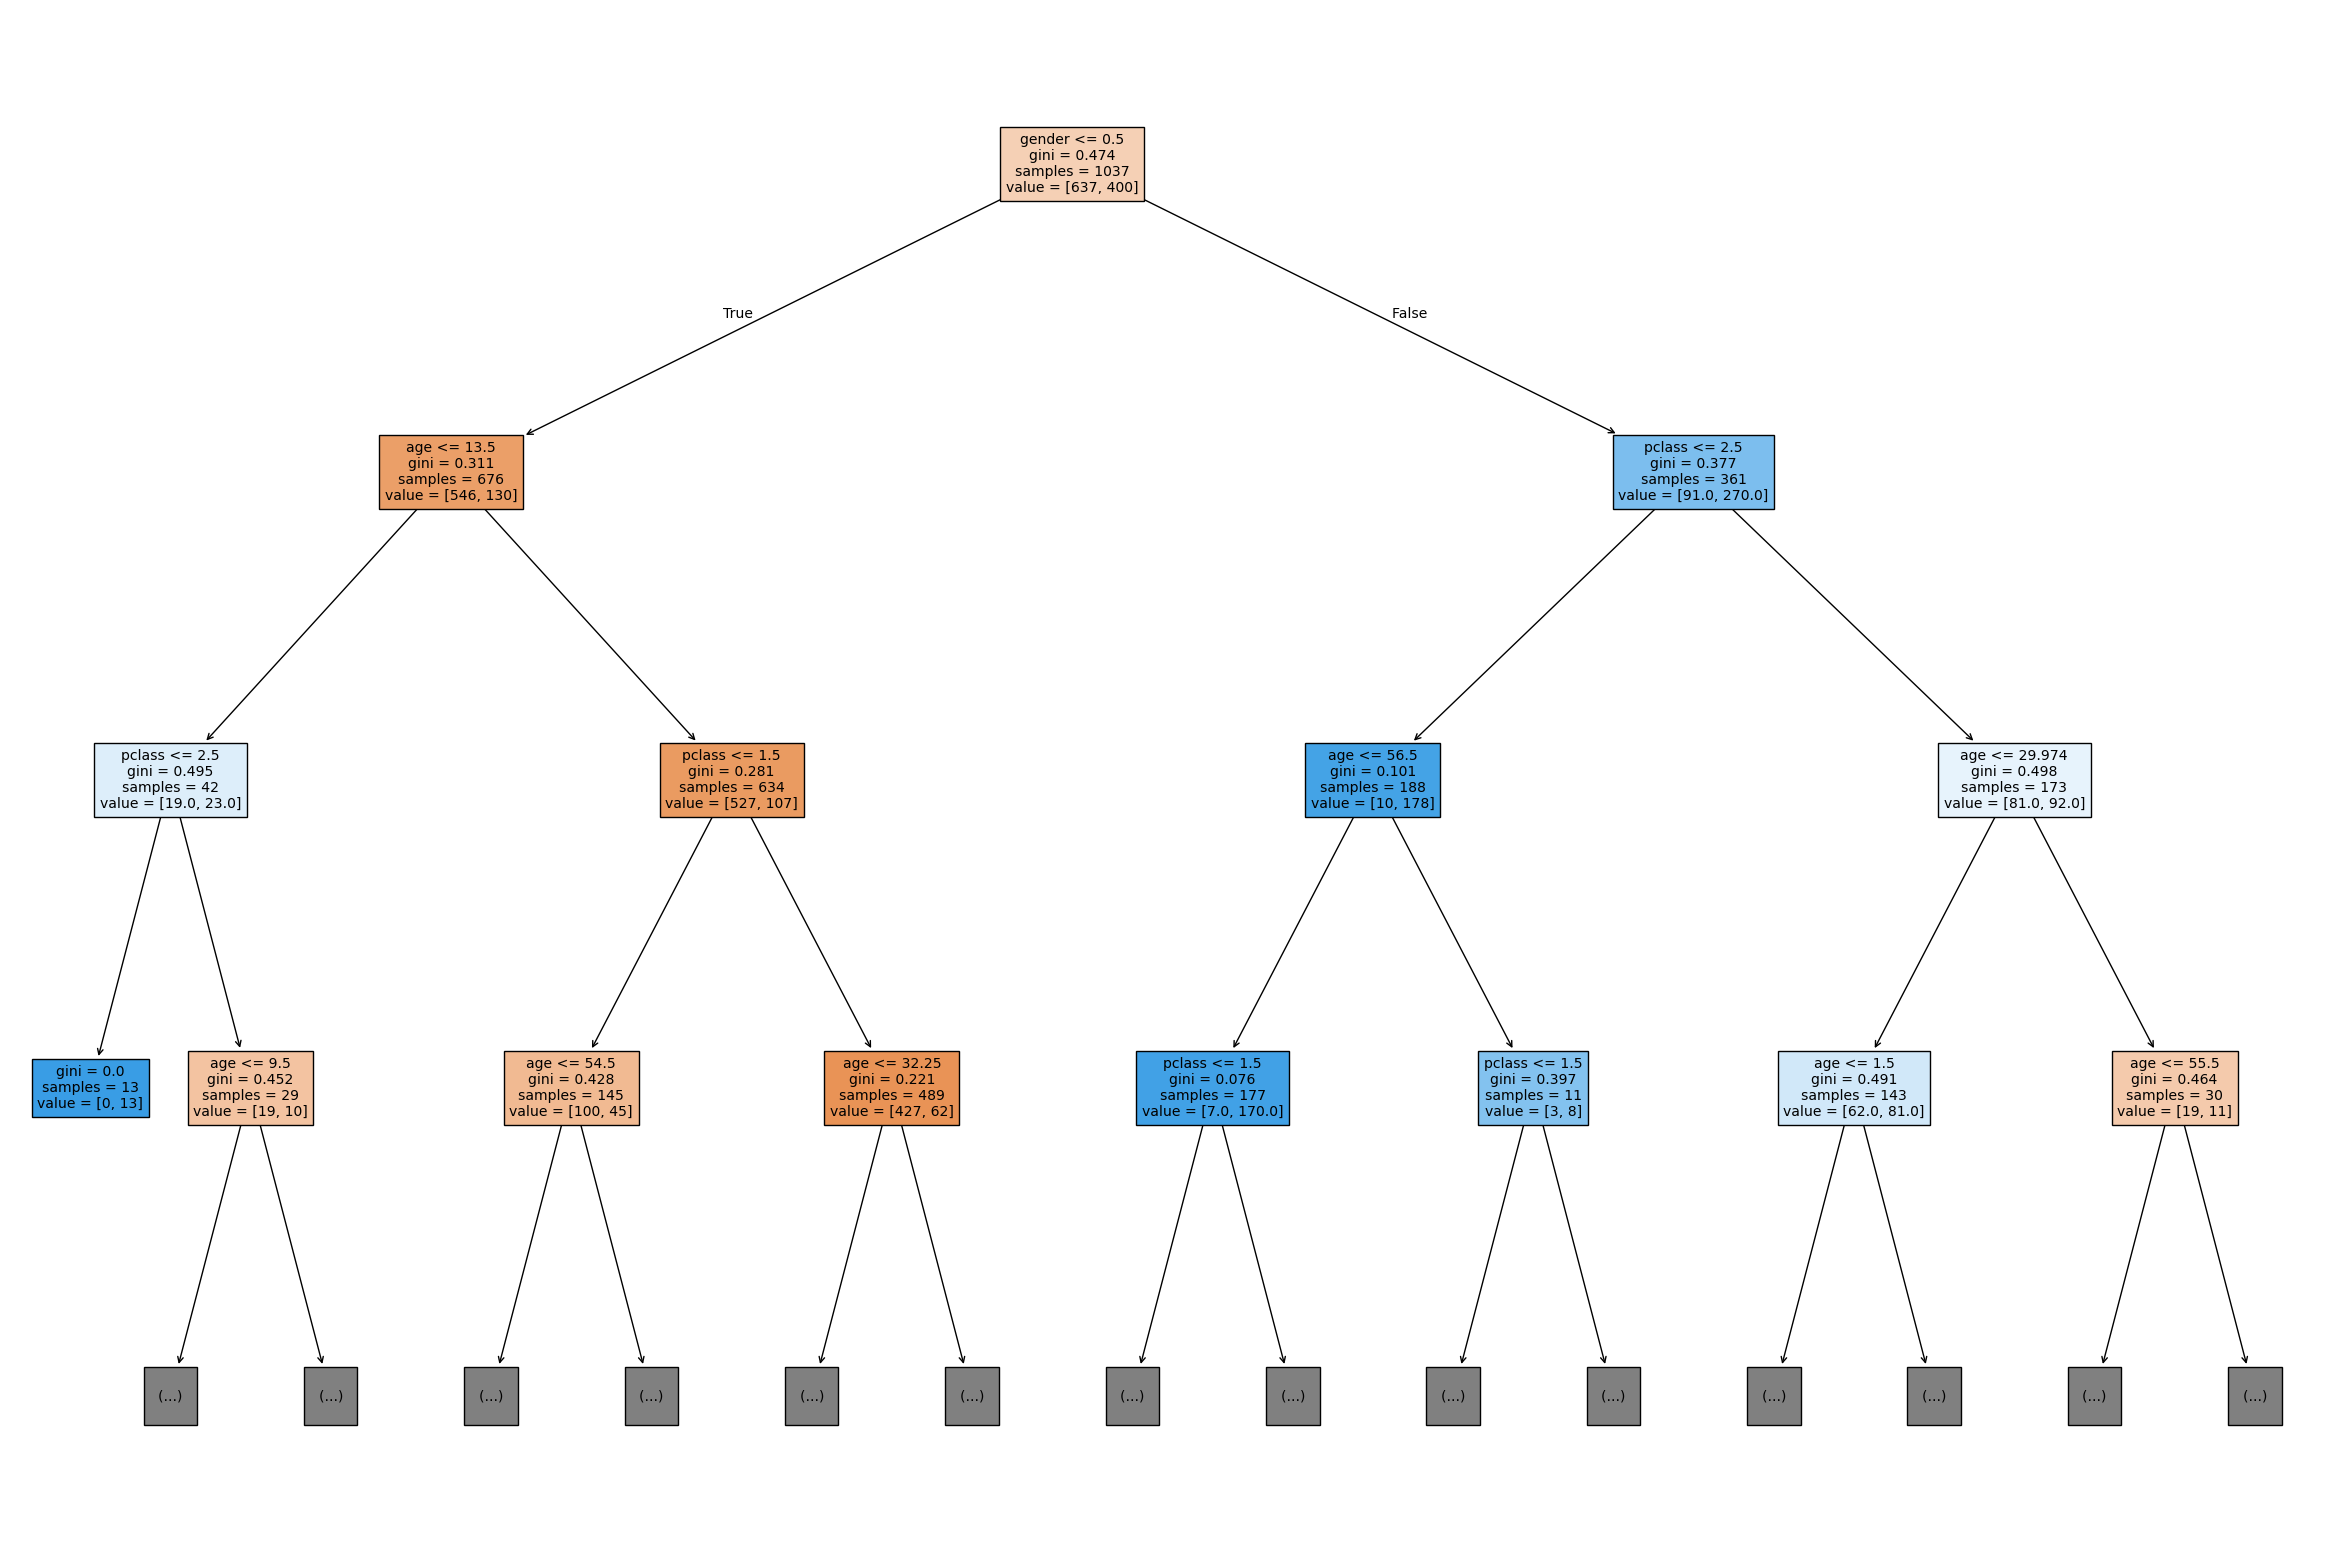

In [206]:
#4. Visualizaing the Tree

plt.figure(figsize=(30, 20))
plot_tree(model, max_depth=3, feature_names=X.columns, filled=True)
plt.show()

4. The first split appears from gender. This choice makes sense because historically, women had a much higher survival rate from the Titanic as women and children were prioritized to be saved in the lifeboats first, so the difference in survival rate between the two listend genders would be quite significant.

In [207]:
#5. Pruning the Tree

model2=DecisionTreeClassifier(max_depth=3)
model2.fit(X_train, y_train)

train_acc2=accuracy_score(y_train, model2.predict(X_train))
test_acc2=accuracy_score(y_test, model2.predict(X_test))
print(train_acc2)
print(test_acc2)

0.8071359691417551
0.7653846153846153


5. max_depth improves performance by preventing more overfitting. It does this task by limiting the amount of useless "noise" in the training data anf forces the machine to analyze patterns more generally.

In [208]:
#6. Random Forest

rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

6. A random forest makes a prediction from the information of multiple single decision trees, ensuring a redcution in error and individual bias.

In [209]:
#7. Confusion Matrix

y_pred=rf.predict(X_test)
confusionmatrix=confusion_matrix(y_test, y_pred)
print(confusionmatrix)

# 32 died but were predicted to have survived (FP) and 27 survived but were predicted to have died (FN)

[[126  35]
 [ 28  71]]


In [210]:
#8. Precision + Recall

y_pred=y_pred.astype(int)
y_test=y_test.astype(int)

precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)

print(f' Precision: {precision}')
print(f' Recall: {recall}')

 Precision: 0.6698113207547169
 Recall: 0.7171717171717171


8. Recall is much more important for the goal of "leaving no one behind" because it shows how many people that the model found to have survived over total amount of survivors while precision just shows how many people who survived were predicted correctly by the model. The higher the recall score, the less survivors it indicates to have not been found.  


In [211]:
#9. AUC/ROC Score

from sklearn.metrics import roc_auc_score

probability=rf.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test, probability)
print(auc)

0.816142794403664


9. An AUC score of 0.85 is very good because that means that the model is able to differentiate between the two classes (survived vs died) very well and much better than a random 50/50 coin flip.

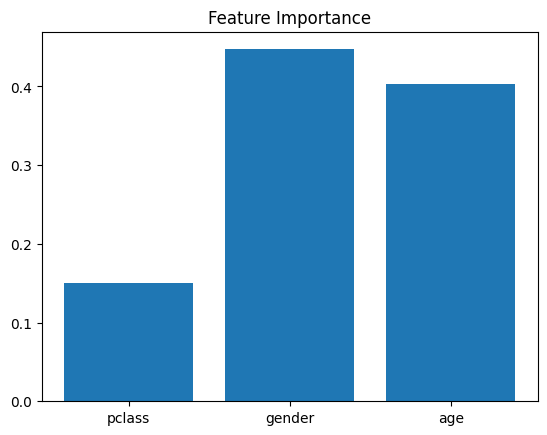

In [212]:
#10. Feature Importance

importances=rf.feature_importances_
features=X.columns

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

10. The three most important features are passenger class, gender, and age. There are many features that are considered useless because they don't appear in the graph, indicating that they have an importance of 0. Some exmaples of useless features include their name, amount of family members, and fare.